Importowanie bibiliotek

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor

Importowanie danych oraz wstępne sprawdzenie ich struktury

In [ ]:
df=pd.read_csv('BostonHousing.csv')
print(df.head())
print(f"\nDatasets shape: {df.shape}")

      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Datasets shape: (506, 14)


Wnioski:
*   wstępny brak pustych pól (NaN)
*   brak nazw (np. lokalizacji), każda cecha to liczba (nie trzeba będzie dawać etykiet liczbowych)
*   brak znaków specjalnych ($) czy nawiasów do usunięcia







Dokładniejsza analiza danych

In [ ]:
print(f"\nDataset description:\n{df.describe()}\n")
print(df.info())
print(f"\nDataset null values:\n{df.isnull().sum()}")
print(f"\nDataset duplicate values:\n{df.duplicated().sum()}")


Dataset description:
             crim          zn       indus        chas         nox          rm  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  501.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284341   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.705587   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.884000   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208000   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.625000   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              age         dis         rad         tax     ptratio           b  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std  

Wnioski:
* brakuje 5 wartości w kolumnie rm (trzeba będzie uzupełnić lub usunąć)
* crim- średnia=3.61, a max=88,98- duża rozpiętość (prawdopodobnie występuje outlier)(trzebasprawdzić rozkład na histogramie+wykres pudełkowy)
* zn- mediana=0 (większkość dzielnic ma działki poniżej 25000 stóp) max=100 (są też dzielnice bardzo rozproszone)
* medv-nasz target- mediana=21.20 (większość domów kosztuje około 21 tys. dolarów), 75%=25 tylko 25% domów kosztuje >25 tys. dolarów
* różna skala zmiennych (tax maksymalnie=711, a chas jest binarną wartością 0-1)- trzeba będzie dokonać standaryzacji lub normalizacji



Wypełnienie brakujących pól w rm

In [ ]:
df['rm']=df["rm"].fillna(df["rm"].median())
df.isna().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


Sprawdzanie korelacji dla df


Korelacja cech względem 'medv':
medv       1.000000
rm         0.695668
zn         0.360445
b          0.333461
dis        0.249929
chas       0.175260
age       -0.376955
rad       -0.381626
crim      -0.388305
nox       -0.427321
tax       -0.468536
indus     -0.483725
ptratio   -0.507787
lstat     -0.737663
Name: medv, dtype: float64



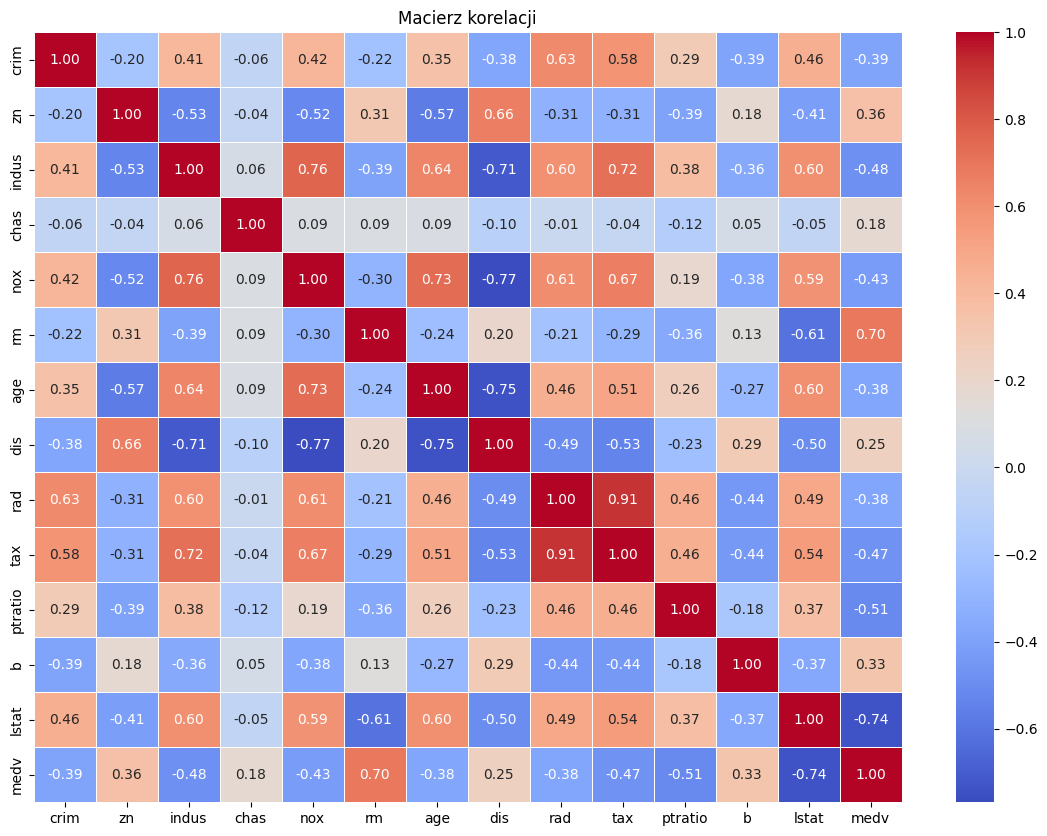

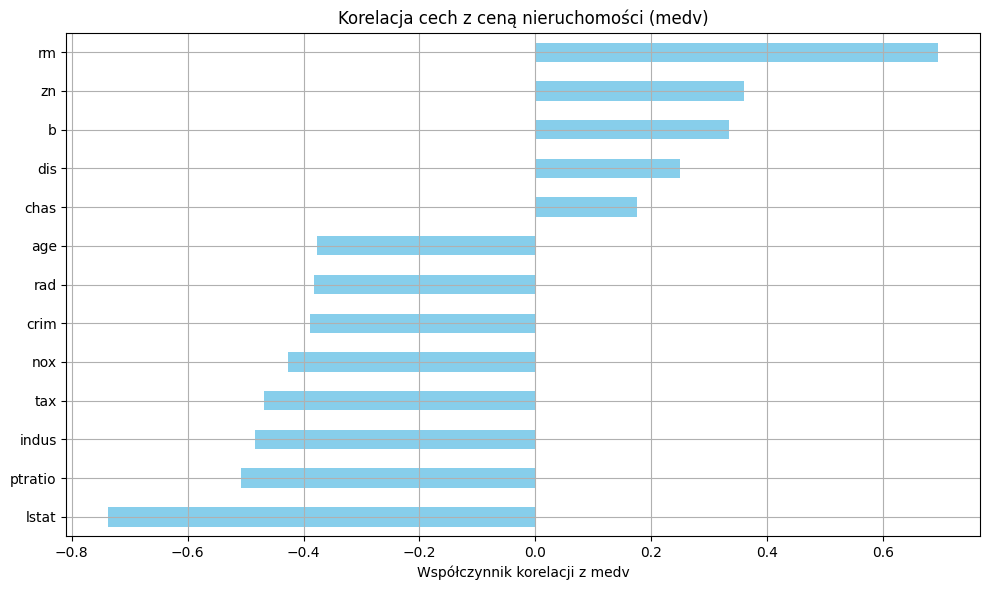

In [ ]:
correlation_matrix = df.corr(numeric_only=True)

target = 'medv'
cor_target = correlation_matrix[target].sort_values(ascending=False)
print(f"\nKorelacja cech względem '{target}':\n{cor_target}\n")

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Macierz korelacji')
plt.show()

plt.figure(figsize=(10, 6))
cor_target.drop(target).sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.xlabel('Współczynnik korelacji z medv')
plt.title('Korelacja cech z ceną nieruchomości (medv)')
plt.grid(True)
plt.tight_layout()
plt.show()

Wnioski:
* można pominąć kolumny: chas, dis, b- mają nikłą korelację z medv
* rm- silna kolidacja(więcej pokoji- wyższa cena)
* lstat- silna ujemna kolidacja(więcej rodzin o niskim statusie społecznym=niższa cena nieruchomości)
* ptratio- ujemna kolidacja (więcej uczniów na nauczyciela= niższa cena)
* indus- ujemna kolidacja (więcej terenów przemysłowych=niższa cena)
* tax- ujemna kolidacja (wyższe podatki=niższa cena)
* nox- ujemna kolidacja (większe zanieczyszczenie powietrza= niższa cena)

Usuwanie kolumn ze słabą korelacją dla df

In [ ]:
df = df.drop(columns=['chas','b'])
print(df.columns)

Index(['crim', 'zn', 'indus', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')


Sprawdzanie rozkładu zmiennych przed standaryzacją dla df

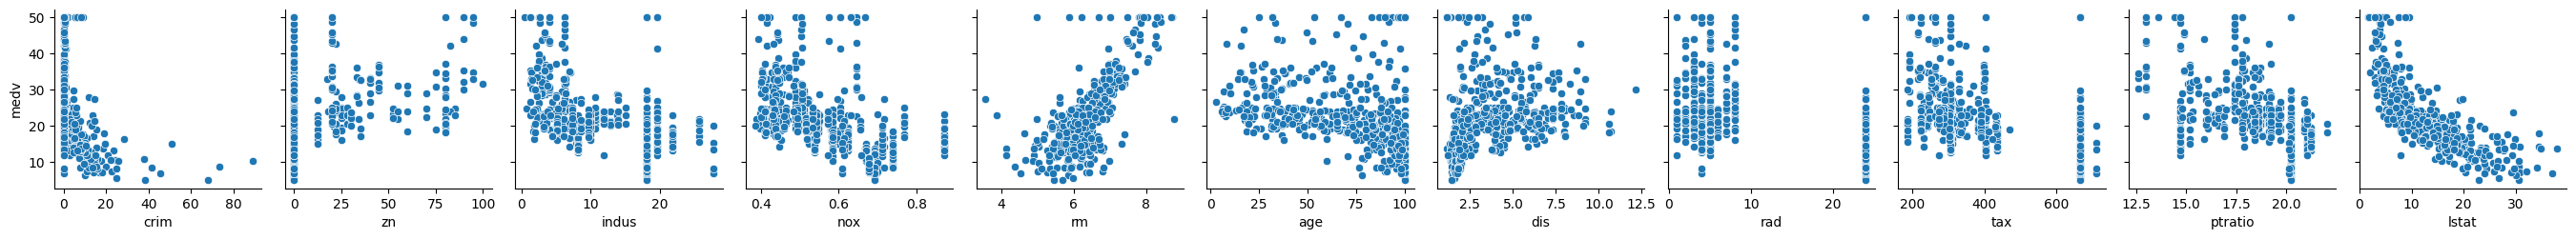

In [ ]:
sns.pairplot(df, y_vars=['medv'], x_vars=df.columns[:-1])
plt.show()

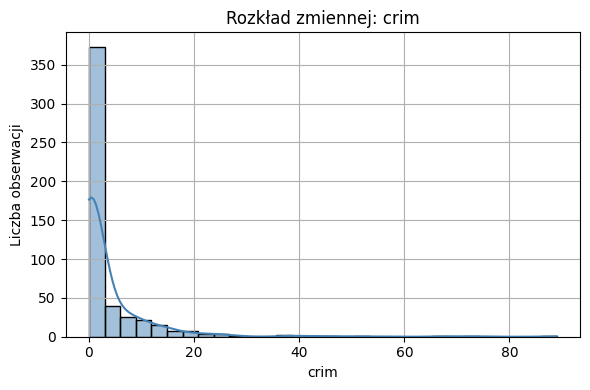

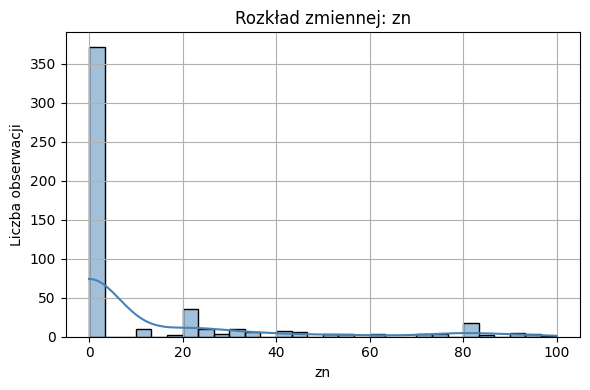

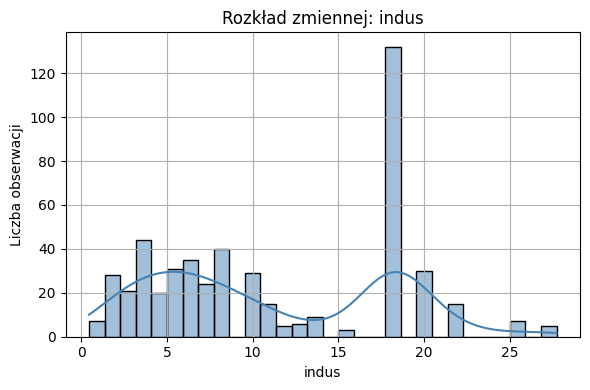

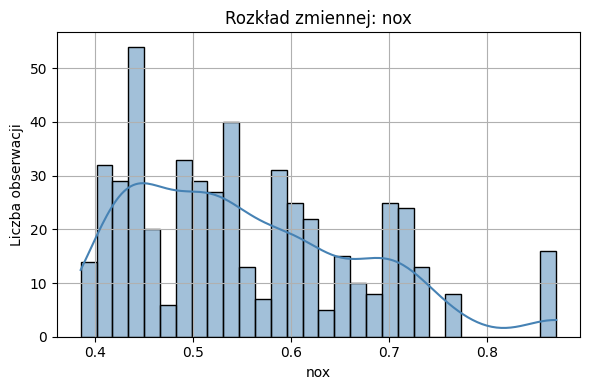

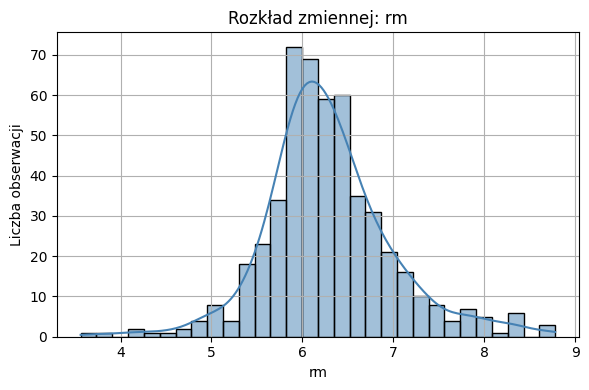

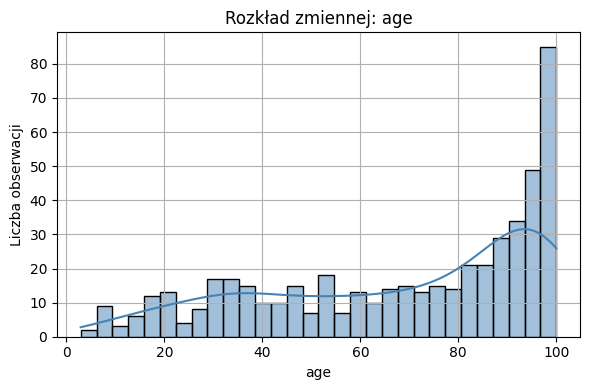

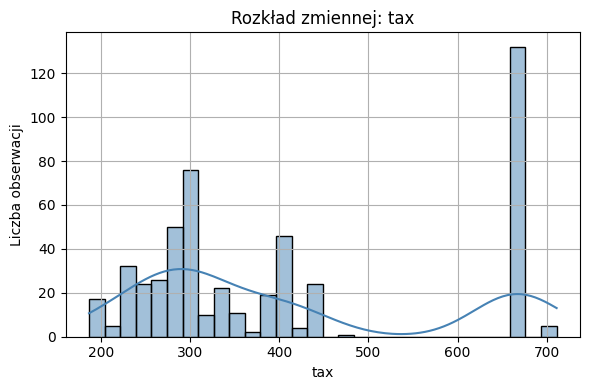

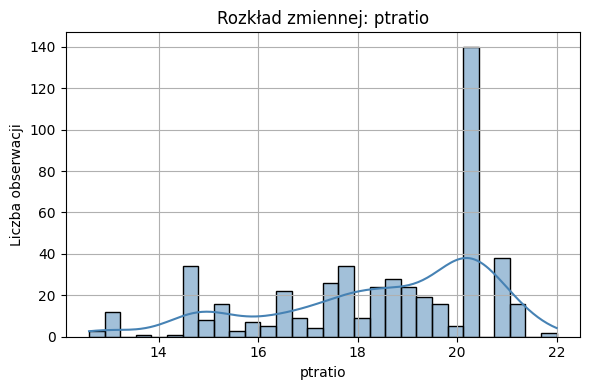

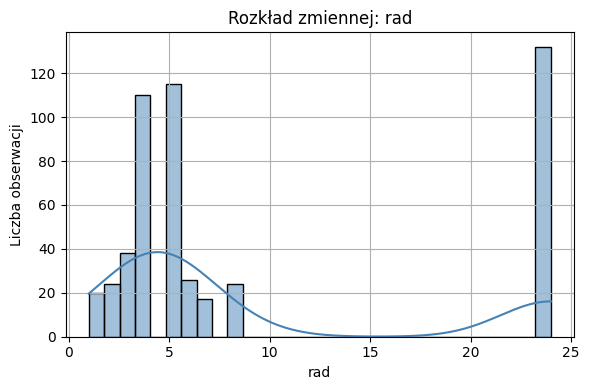

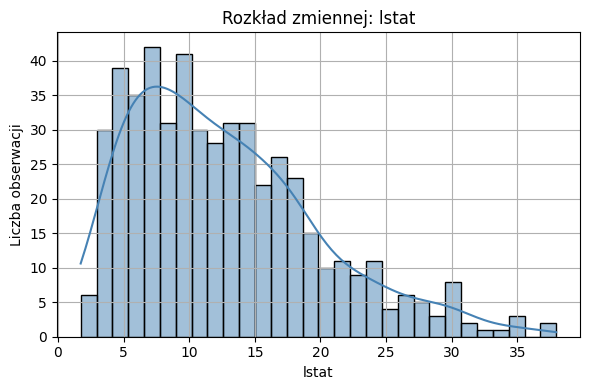

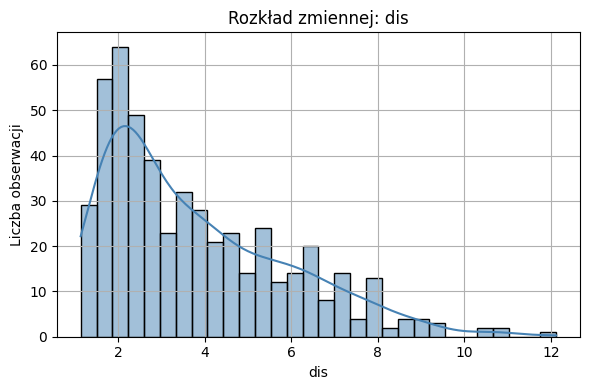

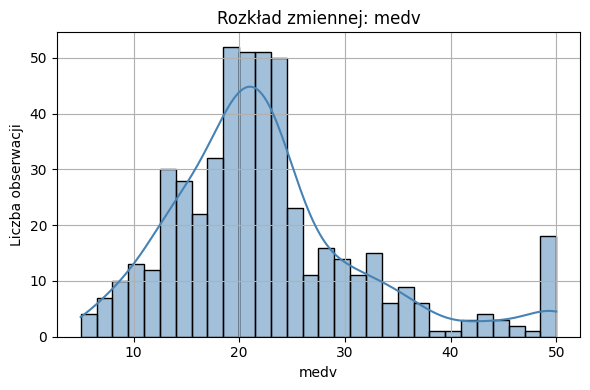

In [ ]:
columns_to_check = ['crim', 'zn', 'indus', 'nox', 'rm', 'age', 'tax', 'ptratio','rad', 'lstat','dis','medv']
for col in columns_to_check:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], bins=30, kde=True, color='steelblue')
    plt.title(f'Rozkład zmiennej: {col}')
    plt.xlabel(col)
    plt.ylabel('Liczba obserwacji')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Wnioski:
* rm, ptratio mają rozkład normalny więc StandardScaler
* crim, zn, lstat, nox, age, indus, tax rozkład skośny (mają "ciągnący się" ogon), więc MinMaxScaler ale dla regresji lepszy będzie RobustScalelr
* rad zostawiamy

INTERAKCJE

Korelacja (rm * lstat) z medv: -0.7297


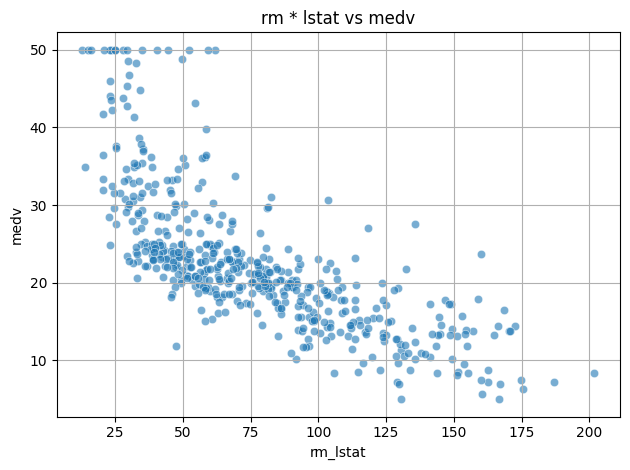

In [ ]:
df['rm_lstat'] = df['rm'] * df['lstat']
cor = df[['rm_lstat', 'medv']].corr().iloc[0, 1]
print(f"Korelacja (rm * lstat) z medv: {cor:.4f}")
sns.scatterplot(x=df['rm_lstat'], y=df['medv'], alpha=0.6)
plt.title("rm * lstat vs medv")
plt.grid(True)
plt.tight_layout()
plt.show()

Standaryzacja dla df  rm, ptratio- StandarsScaler dla crim, zn, lstat, nox, age,indus, tax- RobustScaler



In [ ]:
standard_cols = ['rm', 'ptratio','dis_log']
robust_cols = ['crim', 'zn', 'lstat', 'nox', 'age', 'indus', 'tax','rm_lstat']
unscaled_cols=['rad']
df_scaled = df.copy()
df_scaled['dis_log'] = np.log1p(df['dis'])
scaler_std = StandardScaler()
df_scaled[standard_cols] = scaler_std.fit_transform(df_scaled[standard_cols])
scaler_robust = RobustScaler()
df_scaled[robust_cols] = scaler_robust.fit_transform(df_scaled[robust_cols])
all_used_cols = standard_cols + robust_cols + unscaled_cols
print(df_scaled[all_used_cols].describe())

                 rm       ptratio       dis_log          crim          zn  \
count  5.060000e+02  5.060000e+02  5.060000e+02  5.060000e+02  506.000000   
mean   4.037175e-16 -4.212704e-16 -6.459479e-16  9.337910e-01    0.909091   
std    1.000990e+00  1.000990e+00  1.000990e+00  2.392616e+00    1.865796   
min   -3.881472e+00 -2.707379e+00 -1.752411e+00 -6.959315e-02    0.000000   
25%   -5.675349e-01 -4.880391e-01 -8.431104e-01 -4.852940e-02    0.000000   
50%   -1.077610e-01  2.748590e-01 -1.036192e-01 -7.697835e-18    0.000000   
75%    4.778271e-01  8.065758e-01  8.305727e-01  9.514706e-01    1.000000   
max    3.559026e+00  1.638828e+00  2.651414e+00  2.467838e+01    8.000000   

              lstat         nox         age       indus         tax  \
count  5.060000e+02  506.000000  506.000000  506.000000  506.000000   
mean   1.292417e-01    0.095400   -0.181959    0.112067    0.202163   
std    7.137493e-01    0.662158    0.573881    0.531398    0.435496   
min   -9.625187e-01   

wnioski:
* jeżeli zn i tax będą mieć mały współczynnik lub duży błąd można rozważyć transformację log1p() lub zostawienie poza modelem

Regresja jednowymiarowa dla każdej cechy w df

In [ ]:
X_all = df_scaled.drop(columns='medv')
y = df_scaled['medv']
print("\nRegresja liniowa dla każdej cechy osobno:")
print("="*45)
for col in X_all.columns:
    X_single = df_scaled[[col]]


    X_train, X_test, y_train, y_test = train_test_split(X_single, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    print(f"{col:<10}  ->  R2: {r2:.4f} | MSE: {mse:.4f}")

    """plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X_test[col], y=y_test, label='Rzeczywiste', alpha=0.6)
    sns.lineplot(x=X_test[col], y=y_pred, color='red', label='Regresja liniowa')
    plt.title(f'Regresja: {col} → medv\nR²={r2:.2f}')
    plt.xlabel(col)
    plt.ylabel('medv')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()"""


Regresja liniowa dla każdej cechy osobno:
crim        ->  R2: 0.1587 | MSE: 61.6941
zn          ->  R2: 0.2589 | MSE: 54.3475
indus       ->  R2: 0.2764 | MSE: 53.0637
nox         ->  R2: 0.2052 | MSE: 58.2853
rm          ->  R2: 0.3697 | MSE: 46.2199
age         ->  R2: 0.2400 | MSE: 55.7326
dis         ->  R2: 0.0733 | MSE: 67.9569
rad         ->  R2: 0.1048 | MSE: 65.6517
tax         ->  R2: 0.2413 | MSE: 55.6380
ptratio     ->  R2: 0.3185 | MSE: 49.9764
lstat       ->  R2: 0.5429 | MSE: 33.5195
rm_lstat    ->  R2: 0.5640 | MSE: 31.9744
dis_log     ->  R2: 0.1037 | MSE: 65.7300


Regresja wielomianowa stopnia 2 i 3 dla df

In [ ]:
for degree in [2, 3]:
    print(f"\nREGRESJA WIELOMIANOWA STOPNIA {degree} DLA KAŻDEJ CECHY (na df):")
    print("=" * 65)

    for col in df.drop(columns='medv').columns:
        X_single = df[[col]]
        y = df['medv']


        poly = PolynomialFeatures(degree=degree, include_bias=False)          # cechy wielomianowe
        X_poly = poly.fit_transform(X_single)


        X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)


        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)


        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)

        print(f"{col:<10} | Stopień: {degree} -> R²: {r2:.4f} | MSE: {mse:.2f}")
"""
        # Wykres
        x_plot = X_test[:, 0]
        plt.figure(figsize=(6, 4))
        sns.scatterplot(x=x_plot, y=y_test, label='Rzeczywiste', alpha=0.5)
        sns.lineplot(x=x_plot, y=y_pred, color='red', label=f'Wielomian {degree} st.')
        plt.title(f'{col} → medv | Wielomian {degree} st. | R²={r2:.2f}')
        plt.xlabel(col)
        plt.ylabel('medv')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()"""


REGRESJA WIELOMIANOWA STOPNIA 2 DLA KAŻDEJ CECHY (na df):
crim       | Stopień: 2 -> R²: 0.1807 | MSE: 60.08
zn         | Stopień: 2 -> R²: 0.2334 | MSE: 56.22
indus      | Stopień: 2 -> R²: 0.3054 | MSE: 50.94
nox        | Stopień: 2 -> R²: 0.2174 | MSE: 57.39
rm         | Stopień: 2 -> R²: 0.5154 | MSE: 35.54
age        | Stopień: 2 -> R²: 0.2695 | MSE: 53.57
dis        | Stopień: 2 -> R²: 0.1354 | MSE: 63.40
rad        | Stopień: 2 -> R²: 0.1095 | MSE: 65.31
tax        | Stopień: 2 -> R²: 0.2576 | MSE: 54.44
ptratio    | Stopień: 2 -> R²: 0.3032 | MSE: 51.10
lstat      | Stopień: 2 -> R²: 0.6269 | MSE: 27.36
rm_lstat   | Stopień: 2 -> R²: 0.6001 | MSE: 29.32

REGRESJA WIELOMIANOWA STOPNIA 3 DLA KAŻDEJ CECHY (na df):
crim       | Stopień: 3 -> R²: 0.1792 | MSE: 60.19
zn         | Stopień: 3 -> R²: 0.2924 | MSE: 51.89
indus      | Stopień: 3 -> R²: 0.3312 | MSE: 49.05
nox        | Stopień: 3 -> R²: 0.2227 | MSE: 57.00
rm         | Stopień: 3 -> R²: 0.5281 | MSE: 34.60
age        | St

"\n        # Wykres\n        x_plot = X_test[:, 0]\n        plt.figure(figsize=(6, 4))\n        sns.scatterplot(x=x_plot, y=y_test, label='Rzeczywiste', alpha=0.5)\n        sns.lineplot(x=x_plot, y=y_pred, color='red', label=f'Wielomian {degree} st.')\n        plt.title(f'{col} → medv | Wielomian {degree} st. | R²={r2:.2f}')\n        plt.xlabel(col)\n        plt.ylabel('medv')\n        plt.grid(True)\n        plt.legend()\n        plt.tight_layout()\n        plt.show()"

Niestandardowa regresja wieloraka z selektywnymi stopniami dla df:

In [ ]:
df_poly = pd.DataFrame()

# st 3
df_poly['rm'] = df_scaled['rm']
df_poly['rm²'] = df_scaled['rm'] ** 2
df_poly['rm³'] = df_scaled['rm'] ** 3

df_poly['lstat'] = df_scaled['lstat']
df_poly['lstat²'] = df_scaled['lstat'] ** 2
df_poly['lstat³'] = df_scaled['lstat'] ** 3

df_poly['indus'] = df_scaled['indus']
df_poly['indus²'] = df_scaled['indus'] ** 2
df_poly['indus³'] = df_scaled['indus'] ** 3

df_poly['zn'] = df_scaled['zn']
df_poly['zn²'] = df_scaled['zn'] ** 2
df_poly['zn³'] = df_scaled['zn'] ** 3

df_poly['rad'] = df_scaled['rad']
df_poly['rad²'] = df_scaled['rad'] ** 2
df_poly['rad³'] = df_scaled['rad'] ** 3

df_poly['rm_lstat'] = df_scaled['rm_lstat']
df_poly['rm_lstat²'] = df_scaled['rm_lstat'] ** 2
df_poly['rm_lstat³'] = df_scaled['rm_lstat'] ** 3

# st 1
df_poly['ptratio'] = df_scaled['ptratio']

# st 2
df_poly['tax'] = df_scaled['tax']
df_poly['tax²'] = df_scaled['tax'] ** 2

df_poly['age'] = df_scaled['age']
df_poly['age²'] = df_scaled['age'] ** 2

df_poly['nox'] = df_scaled['nox']
df_poly['nox²'] = df_scaled['nox'] ** 2

df_poly['crim'] = df_scaled['crim']
df_poly['crim²'] = df_scaled['crim'] ** 2

df_poly['dis'] = df_scaled['dis_log']
df_poly['dis²'] = df_scaled['dis_log'] ** 2

y = df_scaled['medv']
X_train, X_test, y_train, y_test = train_test_split(df_poly, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f"\nREGRESJA Z INDYWIDUALNYM STOPNIEM KAŻDEJ CECHY")
print(f"R²:  {r2:.4f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")


REGRESJA Z INDYWIDUALNYM STOPNIEM KAŻDEJ CECHY
R²:  0.8365
MSE: 11.99
RMSE: 3.46
MAE:  2.19


Ridge Regression

In [ ]:
ridge_model = Ridge(alpha=1.0)  # niżej testowanie alpha 1.0 najlepiej
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

r2_ridge = r2_score(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

print(f"\nRIDGE REGRESSION")
print(f"R²:  {r2_ridge:.4f}")
print(f"MSE: {mse_ridge:.2f}")
print(f"RMSE: {rmse_ridge:.2f}")
print(f"MAE:  {mae_ridge:.2f}")


RIDGE REGRESSION
R²:  0.8292
MSE: 12.52
RMSE: 3.54
MAE:  2.24


Dobór alpha

In [ ]:
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}
ridge_cv = GridSearchCV(Ridge(), param_grid, scoring='r2', cv=5)
ridge_cv.fit(X_train, y_train)

print(f"Najlepsze alpha wg GridSearch: {ridge_cv.best_params_['alpha']}")

Najlepsze alpha wg GridSearch: 1


Lasso

In [ ]:
lasso_model = Lasso(alpha=0.1, max_iter=10000)  # większe max_iter dla pewności
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

r2_lasso = r2_score(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

print(f"\nLASSO REGRESSION")
print(f"R²:  {r2_lasso:.4f}")
print(f"MSE: {mse_lasso:.2f}")
print(f"RMSE: {rmse_lasso:.2f}")
print(f"MAE:  {mae_lasso:.2f}")


LASSO REGRESSION
R²:  0.8099
MSE: 13.94
RMSE: 3.73
MAE:  2.28


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.993e+02, tolerance: 3.510e+00
  model = cd_fast.enet_coordinate_descent(


In [ ]:
coef_lasso = pd.Series(lasso_model.coef_, index=X_train.columns)
zero_coef = coef_lasso[coef_lasso == 0].index.tolist()

print(f"\nLASSO wyzerowało {len(zero_coef)} cech:")
print(zero_coef)


LASSO wyzerowało 9 cech:
['lstat', 'lstat³', 'indus', 'indus²', 'indus³', 'zn', 'tax²', 'age', 'age²']


RandomForest

In [ ]:
X_rf = df_scaled[all_used_cols]
y_rf = df_scaled['medv']


X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)


rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train_rf, y_train_rf)
y_pred_rf = rf_model.predict(X_test_rf)


r2_rf = r2_score(y_test_rf, y_pred_rf)
mse_rf = mean_squared_error(y_test_rf, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)

print("\nRANDOM FOREST REGRESSION:")
print(f"R²:  {r2_rf:.4f}")
print(f"MSE: {mse_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"MAE:  {mae_rf:.2f}")


RANDOM FOREST REGRESSION:
R²:  0.8918
MSE: 7.94
RMSE: 2.82
MAE:  2.02


Analiza współczynników


Najbardziej wpływowe cechy wg regresji liniowej:
        Cecha  Współczynnik
15   rm_lstat    -21.063849
3       lstat     16.830209
20       tax²      6.539160
19        tax     -6.217937
0          rm      4.832872
16  rm_lstat²      4.657780
8      indus³     -3.999146
27        dis     -3.389444
7      indus²      3.121824
23        nox     -2.613888
4      lstat²     -2.528688
25       crim     -1.878665
12        rad      1.632520
18    ptratio     -1.558626
17  rm_lstat³     -1.101459
6       indus      1.087383
9          zn      0.901160
24       nox²     -0.886187
28       dis²      0.678949
10        zn²     -0.506518
1         rm²      0.497239
21        age     -0.409410
13       rad²     -0.172574
5      lstat³      0.159580
26      crim²      0.056750
11        zn³      0.054145
2         rm³     -0.021874
22       age²      0.014518
14       rad³      0.004889


<ipython-input-76-660308254>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Współczynnik', y='Cecha', data=coef_df.head(15), palette='coolwarm')


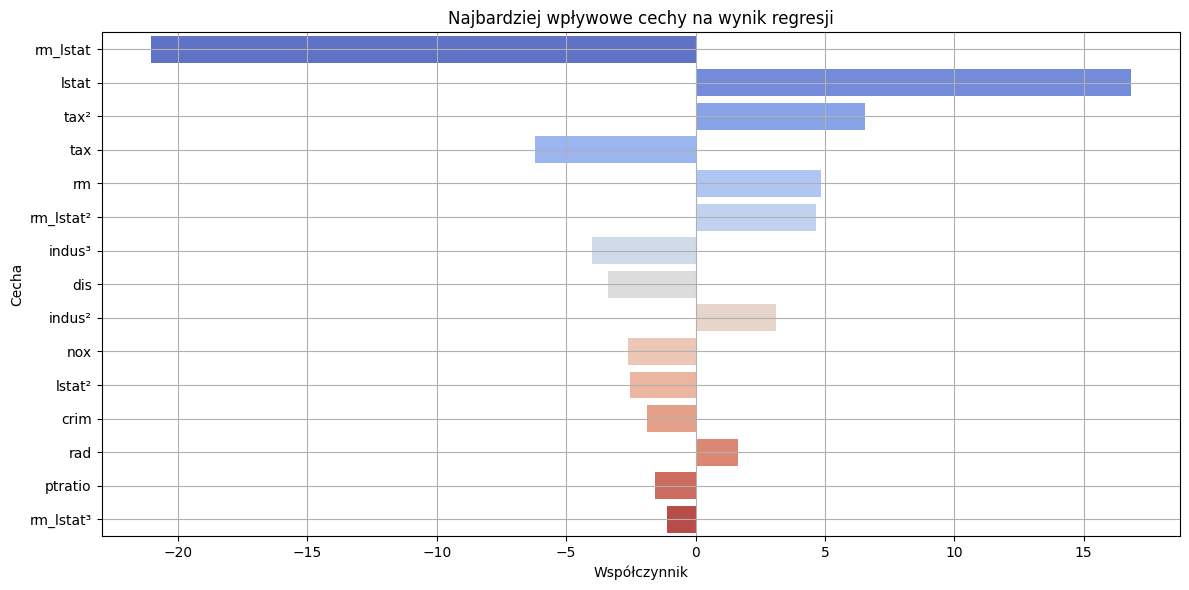

In [ ]:
coef_df = pd.DataFrame({
    'Cecha': X_train.columns,
    'Współczynnik': model.coef_
})


coef_df['Ważność'] = coef_df['Współczynnik'].abs()


coef_df = coef_df.sort_values(by='Ważność', ascending=False)

print("\nNajbardziej wpływowe cechy wg regresji liniowej:")
print(coef_df[['Cecha', 'Współczynnik']])


plt.figure(figsize=(12, 6))
sns.barplot(x='Współczynnik', y='Cecha', data=coef_df.head(15), palette='coolwarm')
plt.title('Najbardziej wpływowe cechy na wynik regresji')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
coef_lasso = pd.Series(lasso_model.coef_, index=X_train.columns)
selected_features = coef_lasso[coef_lasso != 0].index.tolist()

print(f"\nZachowane cechy przez Lasso ({len(selected_features)}):")
print(selected_features)


Zachowane cechy przez Lasso (20):
['rm', 'rm²', 'rm³', 'lstat²', 'zn²', 'zn³', 'rad', 'rad²', 'rad³', 'rm_lstat', 'rm_lstat²', 'rm_lstat³', 'ptratio', 'tax', 'nox', 'nox²', 'crim', 'crim²', 'dis', 'dis²']


In [ ]:
X_train_reduced = X_train[selected_features]
X_test_reduced = X_test[selected_features]
simple_model = LinearRegression()
simple_model.fit(X_train_reduced, y_train)
y_pred_simple = simple_model.predict(X_test_reduced)

r2_simple = r2_score(y_test, y_pred_simple)
mse_simple = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
mae_simple = mean_absolute_error(y_test, y_pred_simple)

print(f"\nUPROSZCZONY MODEL (na {len(selected_features)} cechach)")
print(f"R²:  {r2_simple:.4f}")
print(f"MSE: {mse_simple:.2f}")
print(f"RMSE: {rmse_simple:.2f}")
print(f"MAE:  {mae_simple:.2f}")


UPROSZCZONY MODEL (na 20 cechach)
R²:  0.8363
MSE: 12.00
RMSE: 3.46
MAE:  2.21


Porównanie graficzne modeli

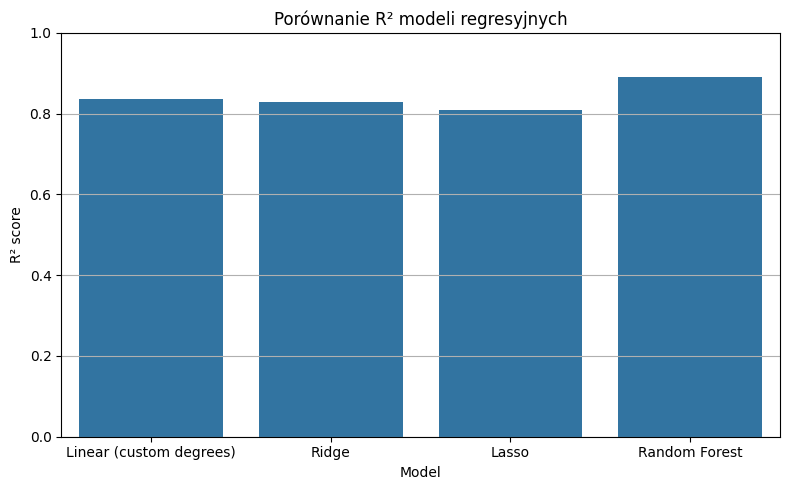

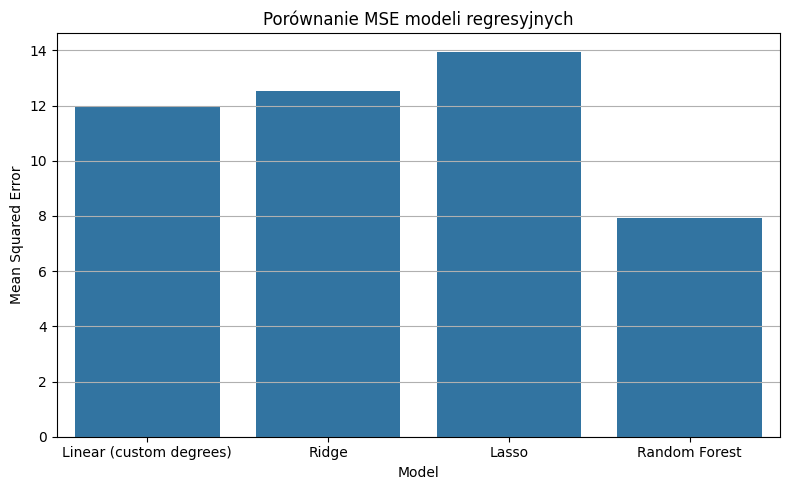

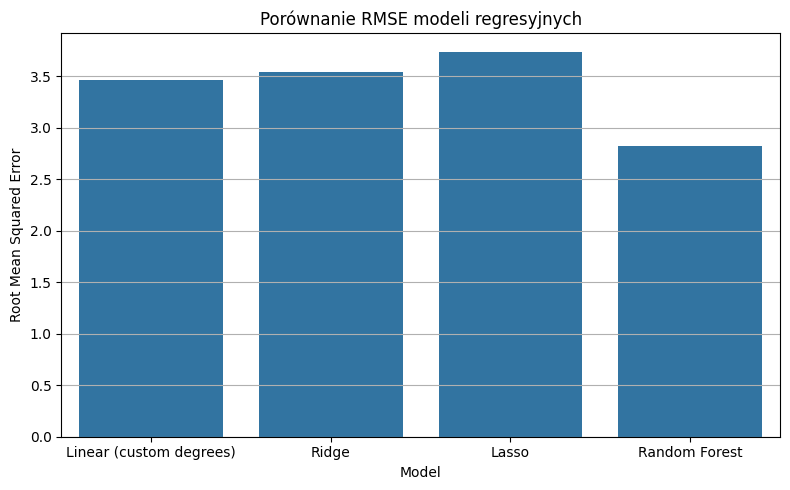

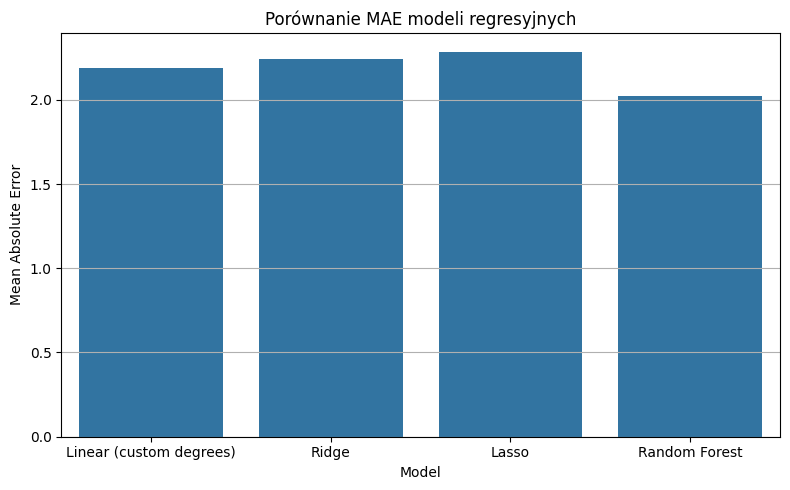

In [ ]:
model_names = ['Linear (custom degrees)', 'Ridge', 'Lasso', 'Random Forest']
r2_scores = [r2, r2_ridge, r2_lasso, r2_rf]
mse_scores = [mse, mse_ridge, mse_lasso, mse_rf]
rmse_scores = [rmse, rmse_ridge, rmse_lasso, rmse_rf]
mae_scores = [mae, mae_ridge, mae_lasso, mae_rf]


results_df = pd.DataFrame({
    'Model': model_names,
    'R²': r2_scores,
    'MSE': mse_scores,
    'RMSE': rmse_scores,
    'MAE': mae_scores
})

#  R²
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='R²', data=results_df)
plt.title('Porównanie R² modeli regresyjnych')
plt.ylim(0, 1)
plt.ylabel('R² score')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='MSE', data=results_df)
plt.title('Porównanie MSE modeli regresyjnych')
plt.ylabel('Mean Squared Error')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()
#  RMSE
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='RMSE', data=results_df)
plt.title('Porównanie RMSE modeli regresyjnych')
plt.ylabel('Root Mean Squared Error')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

#  MAE
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='MAE', data=results_df)
plt.title('Porównanie MAE modeli regresyjnych')
plt.ylabel('Mean Absolute Error')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

Analiza reszt

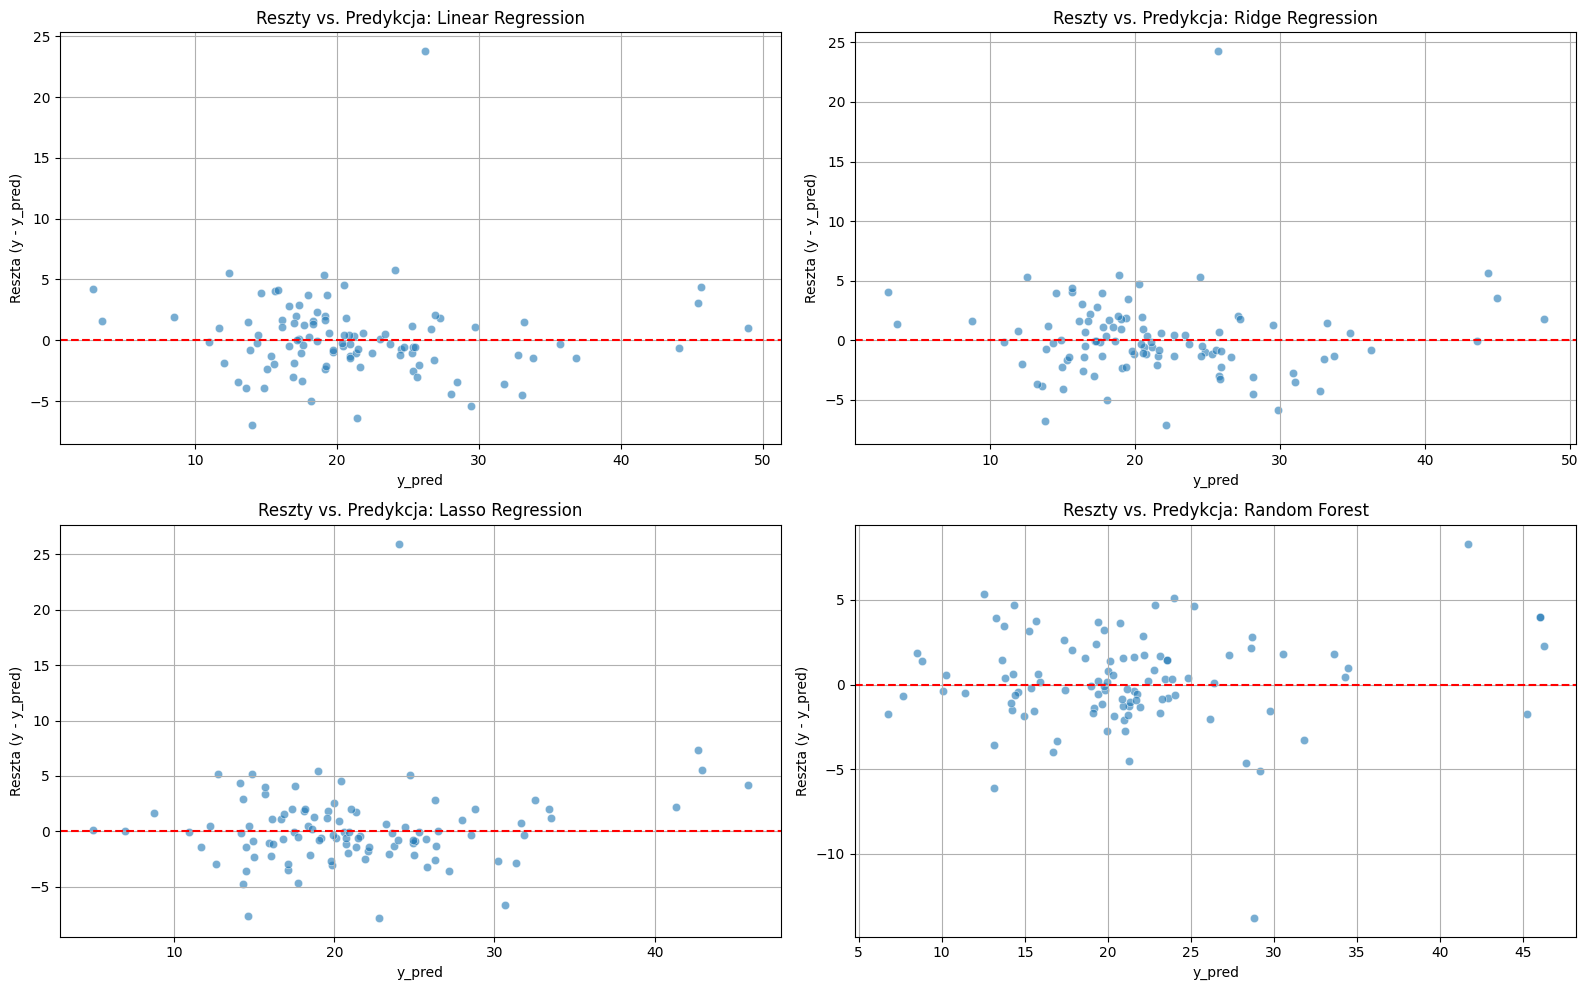

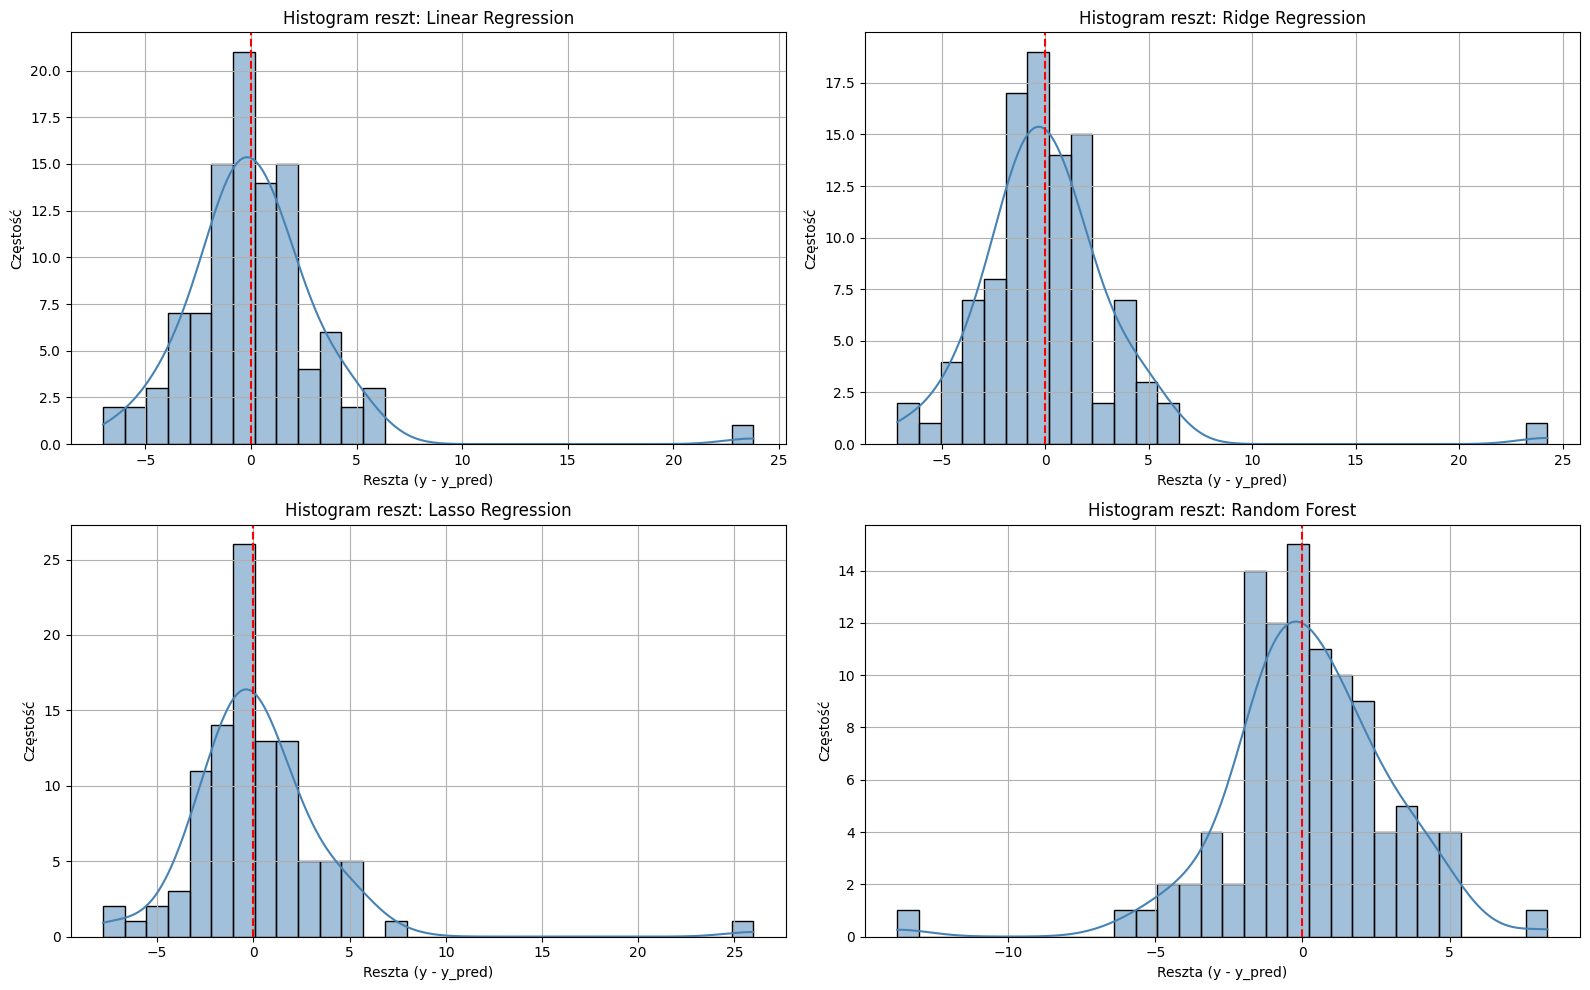

In [ ]:
residuals_linear = y_test - y_pred
residuals_ridge = y_test - y_pred_ridge
residuals_lasso = y_test - y_pred_lasso
residuals_rf = y_test_rf - y_pred_rf
residuals_list = [residuals_linear, residuals_ridge, residuals_lasso, residuals_rf]
preds_list = [y_pred, y_pred_ridge, y_pred_lasso, y_pred_rf]
titles = ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Random Forest']

plt.figure(figsize=(16, 10))
for i, (res, pred, title) in enumerate(zip(residuals_list, preds_list, titles)):
    plt.subplot(2, 2, i + 1)
    sns.scatterplot(x=pred, y=res, alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Reszty vs. Predykcja: {title}')
    plt.xlabel('y_pred')
    plt.ylabel('Reszta (y - y_pred)')
    plt.grid(True)

plt.tight_layout()
plt.show()
plt.figure(figsize=(16, 10))
for i, (res, title) in enumerate(zip(residuals_list, titles)):
    plt.subplot(2, 2, i + 1)
    sns.histplot(res, bins=30, kde=True, color='steelblue')
    plt.axvline(0, color='red', linestyle='--')
    plt.title(f'Histogram reszt: {title}')
    plt.xlabel('Reszta (y - y_pred)')
    plt.ylabel('Częstość')
    plt.grid(True)

plt.tight_layout()
plt.show()

predykcja dla nowych danych

In [ ]:
new_data = pd.DataFrame([{
    'crim': 0.05,
    'zn': 20.0,
    'indus': 5.0,
    'nox': 0.45,
    'rm': 6.0,
    'age': 30.0,
    'tax': 300.0,
    'ptratio': 15.0,
    'rad': 4.0,
    'lstat': 5.0,
    'dis': 4.0
}])

new_data['rm_lstat'] = new_data['rm'] * new_data['lstat']
new_data['dis_log'] = np.log1p(new_data['dis'])

#skalowanie
new_data_scaled = pd.DataFrame()


new_data_scaled[standard_cols] = scaler_std.transform(new_data[standard_cols])


new_data_scaled[robust_cols] = scaler_robust.transform(new_data[robust_cols])

# nieskalowane
new_data_scaled[unscaled_cols] = new_data[unscaled_cols].values

# ta sama kolejnosc kolumn
new_data_scaled = new_data_scaled[all_used_cols]
predicted_price = rf_model.predict(new_data_scaled)[0]
print(f"Przewidywana cena nieruchomości: {predicted_price:.2f} (w dziesiątkach tysięcy dolarów)")

Przewidywana cena nieruchomości: 23.47 (w dziesiątkach tysięcy dolarów)
